In [1]:
%matplotlib widget
import sphWarpCore_config as swc
from typing import Any
swc.configure(precision="float32", dim=Any) # precision: float16|half|float32|single|float64|double
# dim: int or "Any"
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'
import warp as wp; wp.init()

import torch
# from compressibleSPH.gencase import *
from compressibleSPH.sample import generateInitialVariables, SamplingScheme
from compressibleSPH.sampling import  sampleParticles
# from waves.util import plotState, plotInitialState
# from simulation import runSimulation
from compressibleSPH.utils import getCurrentTimestamp
from argparse import ArgumentParser
from compressibleSPH.casefile import argparse_defaults_from_casefile, load_casefile

# from compressibleSPH.systemv3 import WaveSystemStatev3
from compressibleSPH.sample import smoothState
# from compressibleSPH.systemv3 import WaveSystemv3, f_wave_equation
from integrators.integration import *
from compressibleSPH.utils import *
from sphWarpCore import *
# from compressibleSPH.systemv3 import WaveSystemStatev3

from sphWarpCore.radiusSearch.verlet import *
from sphWarpCore.radius import AdjacencyList
from sphWarpCore.operations import *
from sphWarpCore.enumTypes import *

from sphWarpCore import *
# from waves.sampling import sampleParticles
# from compressibleSPH.systemv3 import sampleInitialWaveState
# from compressibleSPH.systemv3 import computeDt
from compressibleSPH.sampling import finalizeWaveSystemSetup
from compressibleSPH.shape_generation import populateSourceObstacleGridsStructured

from compressibleSPH.config import SimulationConfig, CompressibleSPHConfig
from compressibleSPH.caseUtils.sod import *
from compressibleSPH.util import *
from compressibleSPH.schemes import *
from sphWarpCore.diffusion.viscosity import DiffusionParameters

from diffSPH.enums import ViscositySwitch, KernelType
from torch.profiler import profile, record_function, ProfilerActivity
from tqdm.autonotebook import tqdm

Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:

# from compressibleSPH.configurations.simulationConfig import SimulationConfig, buildConfig
# from compressibleSPH.schemeBuilder import buildScheme
# from compressibleSPH.caseUtils.sedov.initial import buildSedov
# goalRadius = 0.8

# gamma = 5/3
# rho0 = 1
# E0 = 1

# nx = 200
# # gamma = 5/3
# # leftState = sodInitialState(1, 1, 0)
# # rightState = sodInitialState(0.1795, 0.25, 0)
# samplingRatio = 1
# smoothIC = True
# timeLimit = 0.15

# L = 2
# dim = 2
# n_h = 4
# device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
# dtype = torch.float32

# config = SimulationConfig(
#     domain = buildDomainDescription(L, dim, True, device, dtype),
#     dim = dim,
#     kernel = KernelFunctions.B7,
#     targetNeighbors = n_h_to_nH(n_h, dim),
#     supportMode = SupportScheme.Gather,
#     gradientMode = GradientScheme.Difference,
#     laplacianMode = LaplacianScheme.Brookshaw,
#     integrationScheme = IntegrationSchemeType.rungeKutta4,
#     samplingScheme = SamplingScheme.regular,
#     device = device,
#     dtype = dtype,
#     dt = 1e-3,
#     adaptiveDt = False,
#     cflFactor=0.3,
#     verletScale=1.0
# )



# SimulationSystem, SimulationState, SimulationConfig, fn = buildScheme('compSPH')

# compressibleSPHConfig = SimulationConfig(
#     gamma = gamma,
#     rho0 = rho0,
#     # diffusionParams = diffusionParams,
# )
# integrator = getIntegrator(config.integrationScheme)

# from compressibleSPH.enumTypes import ViscositySwitch
# compressibleSPHConfig.viscositySwitchParams.scheme = ViscositySwitch.CullenHopkins

In [3]:
nx = 20
gamma = 5/3
leftState = sodInitialState(1, 1, 0)
rightState = sodInitialState(0.1795, 0.25, 0)
samplingRatio = 1
smoothIC = True
timeLimit = 0.15

L = 2
dim = 2
n_h = 4
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = get_torch_precision()

domain = buildDomainDescription(L, dim, True, device, dtype)
domain.min = torch.tensor([ -1.0, 0.0], device=device, dtype=dtype)
domain.max = torch.tensor([  1.0, 0.2], device=device, dtype=dtype)

config = SimulationConfig(
    domain = domain,
    dim = dim,
    kernel = KernelFunctions.Wendland4,
    targetNeighbors = n_h_to_nH(n_h, dim),
    supportMode = SupportScheme.Gather,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta2,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = 1e-3,
    adaptiveDt = False,
    cflFactor=0.3,
    # verletScale=1.0
)

# diffusionParams = DiffusionParameters()
# diffusionParams.c_s = 1
# diffusionParams.C_l = 1
# diffusionParams.C_q = 2
# diffusionParams.Cu_l = 1
# diffusionParams.Cu_q = 2
# diffusionParams.K = 1.0
# diffusionParams.thermalConductivity = 0.5
# diffusionParams.viscosityTerm = ViscosityTerms.Monaghan1992.value
# diffusionParams.thermalConducitiyTerm = ViscosityTerms.Price2012_98.value
# diffusionParams.scaleBeta = False
# diffusionParams.monaghanSwitch = True
# diffusionParams.correctXi = True


from compressibleSPH.configurations.simulationConfig import SimulationConfig, buildConfig
from compressibleSPH.schemeBuilder import buildScheme

SimulationSystem, SimulationState, SimulationConfig, fn = buildScheme('crkSPH')
rho0 = 1.0
compressibleSPHConfig = SimulationConfig(
    gamma = gamma,
    rho0 = rho0,
    # diffusionParams = diffusionParams,
)
integrator = getIntegrator(config.integrationScheme)

from compressibleSPH.enumTypes import ViscositySwitch
compressibleSPHConfig.viscositySwitchParams.scheme = ViscositySwitch.NoneSwitch

In [4]:
# compSystem = buildSedov(
#     SimulationSystem, SimulationState, 
#     config = config,
#     nx = nx, dim = dim, domainExtent = L, 
#     periodicDomain = True, 
#     rho0 = rho0, E0 = E0, 
#     initialization = 'quadrant', 
#     gamma = gamma, kernel = config.kernel, 
#     targetNeighbors = config.targetNeighbors, 
#     dtype = config.dtype, device = config.device)

In [5]:

from warp import Kernel

from compressibleSPH.config import SimulationConfig
from compressibleSPH.utils import *
from sphWarpCore import *
import torch
from compressibleSPH.system import *
from compressibleSPH.modules import idealGasEOS, evaluateOptimalSupport
from compressibleSPH.enumTypes import *
# from optimalSupport import evaluateOptimalSupport

# dim = 2
# domain = buildDomainDescription(L, dim, periodic = periodicDomain, device = device, dtype = dtype)

particles_ = sampleRegularParticles(nx, config.domain, config.targetNeighbors)
print(f'Initial number of particles: {particles_.positions.shape[0]}')

# domain = buildDomainDescription(domainExtent * 1.5, dim, periodic = periodicDomain, device = device, dtype = dtype)
particles_ = particles_._replace(masses = particles_.masses * compressibleSPHConfig.rho0)



particles = SimulationState(
    positions = particles_.positions,
    supports = particles_.supports,
    masses = particles_.masses,
    densities = particles_.densities,
    velocities = torch.zeros_like(particles_.positions),
    
    kinds = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
    materials = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
    UIDs = torch.arange(particles_.positions.shape[0], device = device, dtype = torch.int32),
    UIDcounter = particles_.positions.shape[0],
    
    internalEnergies = None,
    totalEnergies = None,
    entropies = None,
    pressures = None,
    soundspeeds = None,

    divergence=torch.zeros_like(particles_.densities),
    alpha0s= torch.ones_like(particles_.densities),
    alphas= torch.ones_like(particles_.densities),
)


densities = warpOperation(
    particles, 
    OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Density,
        supportMode = SupportScheme.Gather,
        gradientMode = config.gradientMode,
        laplacianMode = config.laplacianMode,
    ),
    domain = config.domain,
)
particles.densities = densities

compressibleSPHConfigAdapt = CompressibleSPHConfig(
    adaptiveSupportIterations=16,
    adaptiveSupportThreshold=1e-3,
    adaptiveSupportScheme=AdaptiveSupportScheme.NoScheme,
)

# neighborhood, neighbors = evaluateNeighborhood(particles, domain, wrappedKernel, verletScale = 1.0, mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)
# numNeighbors = coo_to_csr(filterNeighborhoodByKind(particles, neighbors.neighbors, which = 'noghost')).rowEntries
# config = {'targetNeighbors': targetNeighbors, 'domain': domain, 'support': {'iterations': 16, 'scheme': 'Monaghan'}, 'neighborhood': {'algorithm': 'compact'}}
# rho, h, rhos, hs, neighborhood = evaluateOptimalSupport(particles, wrappedKernel, neighborhood, SupportScheme.Gather, config)


rho_optimal, h_optimal, adjacency, rhos_iter, supports_iter = evaluateOptimalSupport(particles, config, supportScheme = SupportScheme.Gather, compParams = compressibleSPHConfigAdapt)


adjacency = buildVerletList(particles, domain = config.domain, verletScale = 1.0, supportMode = SupportScheme.SuperSymmetric, priorNeighborhood=None, verbose=False)

print(f'Optimal Support min: {h_optimal.min()}, max: {h_optimal.max()}, mean: {h_optimal.mean()}')
print(f'Number of neighbors min: {adjacency.numNeighbors.min()}, max: {adjacency.numNeighbors.max()}, mean: {adjacency.numNeighbors.float().mean()}')

Initial number of particles: 4000
Module sphWarpCore.radiusSearch.wp_compactHash e67fccd load on device 'cuda:0' took 2.64 ms  (cached)
Module sphWarpCore.operations_grid.wp_density_grid 82cf6d3 load on device 'cuda:0' took 2.57 ms  (cached)
Optimal Support min: 0.04000000283122063, max: 0.04000000283122063, mean: 0.04000000283122063
Number of neighbors min: 45, max: 49, mean: 47.35000228881836


In [6]:
import math
vs = 1.0
v_initial_y = vs * torch.cos(2 * math.pi * particles.positions[:,0])
v_initial_x = torch.where(particles.positions[:,0] < 0, 1.0, -1.0)

v_initial = torch.stack([v_initial_x, v_initial_y], dim=1)

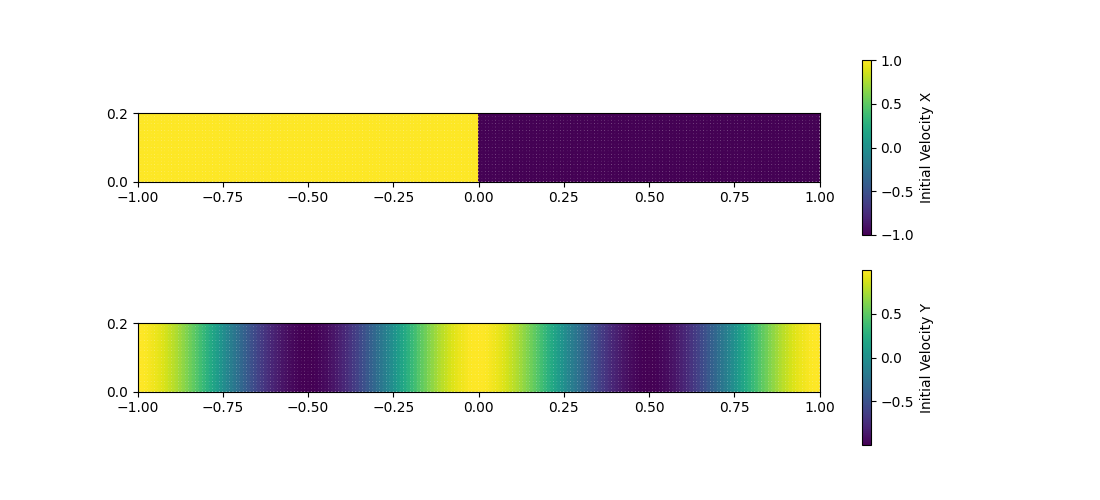

In [7]:
fig, axis = plt.subplots(2, 1, figsize=(11,5), squeeze=False)

sc = axis[0,0].scatter(particles_.positions[:,0].cpu(), particles_.positions[:,1].cpu(), s=5, c = v_initial_x.cpu())
fig.colorbar(sc, ax=axis[0,0], label='Initial Velocity X')

sc = axis[1,0].scatter(particles_.positions[:,0].cpu(), particles_.positions[:,1].cpu(), s=5, c = v_initial_y.cpu())
fig.colorbar(sc, ax=axis[1,0], label='Initial Velocity Y')

for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(config.domain.min[0].cpu(), config.domain.max[0].cpu())
    ax.set_ylim(config.domain.min[1].cpu(), config.domain.max[1].cpu())

In [8]:

# compressibleSPHConfig = CompressibleSPHConfig(
#     adaptiveSupportIterations=16,
#     adaptiveSupportThreshold=1e-3,
#     adaptiveSupportScheme=AdaptiveSupportScheme.Owen,
# )

# neighborhood, neighbors = evaluateNeighborhood(particles, domain, wrappedKernel, verletScale = 1.0, mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)
# numNeighbors = coo_to_csr(filterNeighborhoodByKind(particles, neighbors.neighbors, which = 'noghost')).rowEntries
# config = {'targetNeighbors': targetNeighbors, 'domain': domain, 'support': {'iterations': 16, 'scheme': 'Monaghan'}, 'neighborhood': {'algorithm': 'compact'}}
# rho, h, rhos, hs, neighborhood = evaluateOptimalSupport(particles, wrappedKernel, neighborhood, SupportScheme.Gather, config)

rho_optimal, h_optimal, adjacency, rhos_iter, supports_iter = evaluateOptimalSupport(particles, config, supportScheme = SupportScheme.Gather, compParams = compressibleSPHConfigAdapt)



adjacency = buildVerletList(particles, domain = config.domain, verletScale = 1.0, supportMode = SupportScheme.SuperSymmetric, priorNeighborhood=None, verbose=False)

print(f'Optimal Support min: {h_optimal.min()}, max: {h_optimal.max()}, mean: {h_optimal.mean()}')
print(f'Number of neighbors min: {adjacency.numNeighbors.min()}, max: {adjacency.numNeighbors.max()}, mean: {adjacency.numNeighbors.float().mean()}')

Optimal Support min: 0.04000000283122063, max: 0.04000000283122063, mean: 0.04000000283122063
Number of neighbors min: 45, max: 49, mean: 47.35000228881836


In [9]:

# particleState.supports = h_optimal

particles.densities = rho_optimal
particles.supports = h_optimal

P_initial = torch.zeros_like(particles.densities)
u = 1 / (gamma - 1) * (P_initial / rho_optimal)
# A_, u_, P_, c_s = idealGasEOS(A = None, u = None, P = P_initial, rho = rho_optimal, gamma = gamma)
A_, u_, P_, c_s = idealGasEOS(A = None, u = u, P = None, rho = rho_optimal, gamma = gamma)

internalEnergy = u_ 
kineticEnergy = torch.linalg.norm(torch.zeros_like(particles.positions), dim = -1) **2/ 2
totalEnergy = (internalEnergy + kineticEnergy) * particles.masses

simulationState_ = SimulationState(
    positions = particles.positions,
    supports = particles.supports,
    masses = particles.masses,
    densities = particles.densities,        
    velocities = v_initial,

    kinds = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
    materials = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
    UIDs = torch.arange(particles_.positions.shape[0], device = device, dtype = torch.int32),
    UIDcounter = particles.positions.shape[0],
    
    internalEnergies = u_,
    totalEnergies = totalEnergy,
    entropies = A_,
    pressures = P_,
    soundspeeds = c_s,

    alphas = torch.ones_like(particles.densities),
    alpha0s = torch.ones_like(particles.densities),
    divergence=torch.zeros_like(particles.densities),
)
    

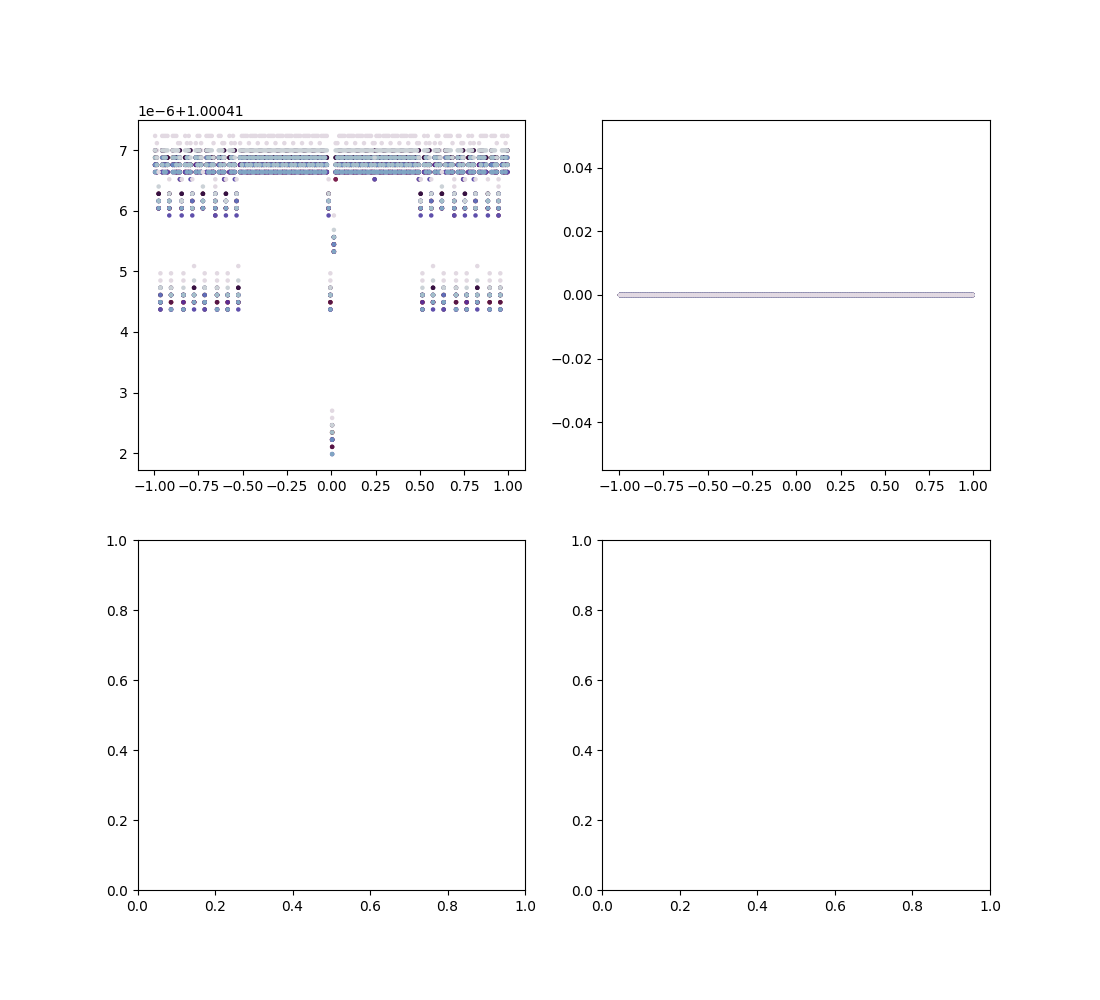

In [10]:
fig, axis = plt.subplots(2, 2, figsize=(11,10), squeeze=False)

axis[0,0].scatter(simulationState_.positions[:,0].cpu(), simulationState_.densities.cpu(), s=5, c = simulationState_.positions[:,1].cpu(), cmap = 'twilight_r')
# fig.colorbar(sc, ax=axis[0,0], label='Final Density')
# axis[0,0].axhline(rho_s, color='red', linestyle='--', label='Theoretical Post-Shock Density')

axis[0,1].scatter(simulationState_.positions[:,0].cpu(), simulationState_.pressures.cpu(), s=5, c = simulationState_.positions[:,1].cpu(), cmap = 'twilight_r')
# fig.colorbar(sc, ax=axis[0,1], label='Final Pressure')
# axis[0,1].axhline(P_s, color='red', linestyle='--', label='Theoretical Post-Shock Pressure')
# axis[0,1].axvline(v_s * runningState.t, color='green', linestyle='--', label='Theoretical Shock Position')



In [11]:
rho_optimal, h_optimal, adjacency, rhos_iter, supports_iter = evaluateOptimalSupport(particles, config, supportScheme = SupportScheme.Gather, compParams = compressibleSPHConfig)
# simulationState_.densities = rho_optimal
adjacency = buildVerletList(
    simulationState_, 
    config.domain, verletScale = 1.4, supportMode = SupportScheme.SuperSymmetric,
    priorNeighborhood = None,
    verbose = False)

apparentVolume, simulationState_.densities, crkState = computeCRKFactors(simulationState_, config.domain, config.kernel, adjacency = adjacency)


P_initial = torch.zeros_like(particles.densities)
# u = 1 / (gamma - 1) * (P_initial / simulationState_.densities)
# A_, u_, P_, c_s = idealGasEOS(A = None, u = None, P = P_initial, rho = rho_optimal, gamma = gamma)
A_, u_, P_, c_s = idealGasEOS(A = None, u = None, P = P_initial, rho = simulationState_.densities, gamma = gamma)
simulationState_.internalEnergies = u_
simulationState_.pressures = P_
simulationState_.soundspeeds = c_s


print(f"min density: {simulationState_.densities.min()}, max density: {simulationState_.densities.max()}")
print(f"min mass: {simulationState_.masses.min()}, max mass: {simulationState_.masses.max()}")
print(f"min support: {simulationState_.supports.min()}, max support: {simulationState_.supports.max()}")

Module sphWarpCore.operations.wp_density f0357bf load on device 'cuda:0' took 2.33 ms  (cached)
Module compressibleSPH.modules.adaptiveSupport.wp_omega 06dd3b2 load on device 'cuda:0' took 2.51 ms  (cached)
Module sphWarpCore.crk.crk_volume 793e787 load on device 'cuda:0' took 3.42 ms  (cached)
Module sphWarpCore.crk.crk_moments 89bc989 load on device 'cuda:0' took 5.25 ms  (cached)
Module sphWarpCore.crk.crk_density 06a7669 load on device 'cuda:0' took 1.49 ms  (cached)
min density: 1.0004140138626099, max density: 1.0004180669784546
min mass: 0.00010000001202570274, max mass: 0.00010000001202570274
min support: 0.04000000283122063, max support: 0.04000000283122063


In [12]:
from compressibleSPH.modules.timestep.compressible import computeTimestep

In [13]:
adjacency = buildVerletList(simulationState_, 
                            domain = config.domain,
                            verletScale = 2**(1/config.dim), supportMode = config.supportMode)

compressibleSystem = SimulationSystem(
    state=simulationState_, 
    adjacency = adjacency, 
    domain = config.domain)

# particleSystem = SimulationSystem(
#     systemState = simulationState_,
#     domain = domain,
#     neighborhoodInfo = neighborhood,
#     t = 0
# )

config.dx = L / nx
config.adaptiveDt = True
config.dt = computeTimestep(compressibleSystem, config, compressibleSPHConfig, dt = None)
print(f'Initial timestep: {config.dt}')

Initial timestep: 0.009999999776482582


In [14]:
from compressibleSPH.schemes.compSPH import compSPH_step

In [15]:
# runningState = compSPHSystem.initializeNewState()

# result = integrator.function(
#     state = runningState,
#     f = compSPH_step,
#     dt = config.dt,  
#     config = config,
#     compParams = compSPHConfig,
#     verbose = False,|
# )
compressibleSPHConfig.energyScheme = EnergyScheme.CRK
compressibleSPHConfig.adaptiveSupportScheme = AdaptiveSupportScheme.NoScheme

In [16]:
runningState = compressibleSystem.initializeNewState()

In [17]:
display(compressibleSPHConfig)

CRKSPHConfig(gamma=1.6666666666666667, backgroundPressure=0.0, rho0=1.0, adaptiveSupportScheme=<AdaptiveSupportScheme.NoScheme: 0>, adaptiveSupportIterations=1, adaptiveSupportThreshold=0.001, adaptiveSupportCorrections=True, diffusionParams=DiffusionParameters(
	c_s=1,
	C_l=1,
	C_q=1,
	Cu_l=1,
	Cu_q=1,
	K=1.0,
	thermalConductivity=0.5,
	viscosityTerm=3,
	thermalConducitiyTerm=7,
	scaleBeta=False,
	monaghanSwitch=True,
	correctXi=True,
), viscositySwitchParams=ViscositySwitchConfig(scheme=<ViscositySwitch.NoneSwitch: 6>, limitXi=True, correctVelocityGradient=False, divergenceScheme='naive', alpha_min=0.02, alpha_max=2.0, beta_c=0.7, beta_d=0.05, beta_xi=2.0), schemeName='CRKSPH', boundaryConditions=[], energyScheme=<EnergyScheme.CRK: 5>, crkViscosityParams=CRKViscosity(
	eta_fold=0.2,
	eta_crit=0.3333333,
	enableCRKLimiter=True,
	enableVanLeerLimiter=True,
	forceVanLeerOff=False,
	forceVanLeerOn=False,
), compatibleEnergy=True)

In [18]:
from warpPlot import visualize, PlottingOptions, PlotScaling, GridVisualization, UniformColorMap, Mapping, DivergingColorMap
markerSize = 2
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.velocities,
        "B": runningState.state.densities,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            mapping = Mapping.x,
            plotTitle = "velocities",
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
            # vMin=1e-10
        ),
        "B": PlottingOptions(
            colorMap = UniformColorMap.cividis,
            flipColorMap=True,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "densities",
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'AB',
    figsize= (11,5),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

# if args.exportImages:
#     plotter.export(f'output/{folderName}/frame_00000.png', dpi = args.figureDpi)

RFBOutputContext()

In [19]:
runningState.state.densities

tensor([1.0004, 1.0004, 1.0004,  ..., 1.0004, 1.0004, 1.0004], device='cuda:0')

In [20]:
config.dt = 2.5e-4
t_limit = 0.6
nSteps = int(t_limit / config.dt)

print(f"Running with dt: {config.dt}, which gives nSteps: {nSteps}")
# nSteps = 256

runningState = compressibleSystem.initializeNewState()
# runningState.state.velocities = torch.zeros_like(runningState.state.positions)
# runningState.state.velocities[:,0] = -1.
trajectory = []

priorStep = None
for i in (tq := tqdm(range(nSteps), leave = True)):
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    begin.record()
    result = integrator.function(
        state = runningState,
        f = fn,
        dt = config.dt,  
        config = config,
        compParams = compressibleSPHConfig,
        verbose = False,
        # priorStep = priorStep
    )
    end.record()
    torch.cuda.synchronize()
    priorStep = result.stages[-1]
    timing = begin.elapsed_time(end)

    runningState = result.state
    kineticEnergy = 0.5 * (torch.linalg.norm(runningState.state.velocities, dim = -1) **2 * runningState.state.masses).sum()
    thermalEnergy = (runningState.state.internalEnergies * runningState.state.masses).sum()
    totalEnergy = kineticEnergy + thermalEnergy

    trajectory.append(
        (i, (i+1)*config.dt, totalEnergy.item(), kineticEnergy.item(), thermalEnergy.item(), timing)
,     )


    if i % 10 == 0 and i > 0:
        plotter.updateQuantities(
            {
                "A": runningState.state.velocities,
                "B": runningState.state.densities,
            },
            newParticleState = runningState.state,
        )
        # axis[0,0].clear()
        # axis[0,1].clear()
        # axis[1,0].clear()
        # axis[1,1].clear()
        # plotShock(fig, axis, runningState)
        # fig.canvas.draw()
        # fig.canvas.flush_events()
        # fig.savefig(f'output/sedov/frame_{i:05d}.png', dpi = 300)

    maxVel = torch.linalg.norm(runningState.state.velocities, dim = -1).max()
    tq.set_description(f"Step {i+1}/{nSteps}, time: {(i+1)*config.dt:8.4g}/{t_limit:8.4g}, TE: {totalEnergy:.3g}, KE: {kineticEnergy:.3g}, IE: {thermalEnergy:.3g} | max vel: {maxVel:.3g} | iter time: {timing:.3f} ms")
    # t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}'
    # break

Running with dt: 0.00025, which gives nSteps: 2400


  0%|          | 0/2400 [00:00<?, ?it/s]

Module sphWarpCore.operations.wp_gradient a50c471 load on device 'cuda:0' took 3.98 ms  (cached)
Module compressibleSPH.modules.crk.accel 9056830 load on device 'cuda:0' took 2.94 ms  (cached)
Module compressibleSPH.modules.crk.dudt 7e9ded3 load on device 'cuda:0' took 3.09 ms  (cached)
Module compressibleSPH.modules.compSPH.balance 8be6a68 load on device 'cuda:0' took 4.33 ms  (cached)


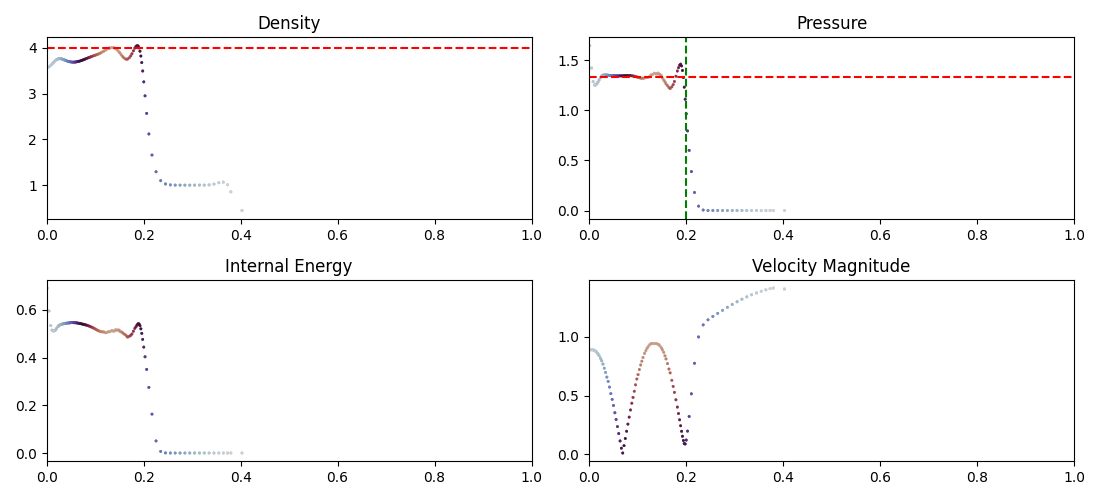

In [21]:

v_s = 1/3
rho_s = rho0 * ((gamma+1) / (gamma-1))**1
P_s = v_s * rho_s

fig, axis = plt.subplots(2, 2, figsize=(11,5), squeeze=False)

particleState = runningState.state

s = 1
alpha = 0.1
sc = axis[0,0].scatter(particleState.positions[:,0].cpu(), particleState.densities.cpu(), s=s, alpha=alpha, c = particleState.positions[:,1].cpu(), cmap = 'twilight_r')
# fig.colorbar(sc, ax=axis[0,0], label='Final Density')
axis[0,0].axhline(rho_s, color='red', linestyle='--', label='Theoretical Post-Shock Density')

sc = axis[0,1].scatter(particleState.positions[:,0].cpu(), particleState.pressures.cpu(), s=s, alpha=alpha, c = particleState.positions[:,1].cpu(), cmap = 'twilight_r')
# fig.colorbar(sc, ax=axis[0,1], label='Final Pressure')
axis[0,1].axhline(P_s, color='red', linestyle='--', label='Theoretical Post-Shock Pressure')
axis[0,1].axvline(v_s * runningState.t, color='green', linestyle='--', label='Theoretical Shock Position')

sc = axis[1,0].scatter(particleState.positions[:,0].cpu(), particleState.internalEnergies.cpu(), s=s, alpha=alpha, c = particleState.positions[:,1].cpu(), cmap = 'twilight_r')
# fig.colorbar(sc, ax=axis[1,0], label='Final Internal Energy')

sc = axis[1,1].scatter(particleState.positions[:,0].cpu(), torch.linalg.norm(particleState.velocities, dim=-1).cpu(), s=s, alpha=alpha, c = particleState.positions[:,1].cpu(), cmap = 'twilight_r')
# fig.colorbar(sc, ax=axis[1,1], label='Final Velocity Magnitude')

axis[0,0].set_title('Density')
axis[0,1].set_title('Pressure')
axis[1,0].set_title('Internal Energy')
axis[1,1].set_title('Velocity Magnitude')

for ax in axis.flatten():
    ax.set_xlim(0, config.domain.max[0].cpu())

fig.tight_layout()

Module sphWarpCore.operations_grid.wp_interpolate_grid bde6e7c load on device 'cuda:0' took 6.85 ms  (cached)


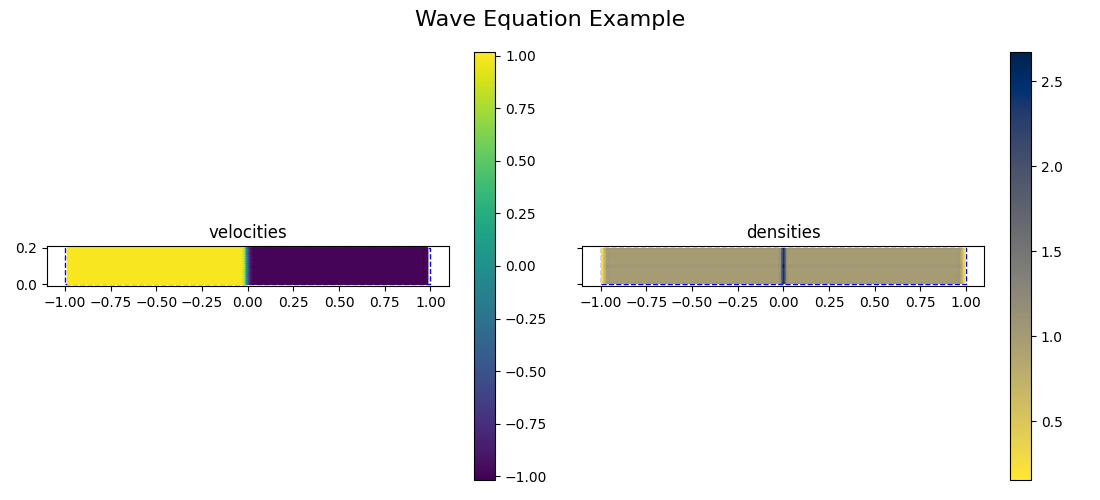

In [69]:
from warpPlot import visualize, PlottingOptions, PlotScaling, GridVisualization, UniformColorMap, Mapping, DivergingColorMap
markerSize = 2
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.velocities,
        "B": runningState.state.densities,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            mapping = Mapping.x,
            plotTitle = "velocities",
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
            # vMin=1e-10
        ),
        "B": PlottingOptions(
            colorMap = UniformColorMap.cividis,
            flipColorMap=True,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "densities",
            gridVisualization = GridVisualization(
                resolution = 512,
            ),
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'AB',
    figsize= (11,5),
    backend='matplotlib',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

# if args.exportImages:
#     plotter.export(f'output/{folderName}/frame_00000.png', dpi = args.figureDpi)